In [1]:
# Statistics

In [2]:
# Import relevant Python packages:
import xarray as xr
import numpy as np
import polars as pl
import matplotlib.pyplot as plt

# Following pip installation as shown on the LT Toolbox github:
import lt_toolbox as ltt
import gsw.density as density

# Searching the OceanDataCatalog dataset

from OceanDataStore import OceanDataCatalog

catalog = OceanDataCatalog(catalog_name="noc-model-stac")

#catalog.available_collections

#Era 5 probs the best here

#Searching the ERA5 collection
#catalog.search(collection='noc-npd-era5')
#catalog.available_items

t1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca025-era5v1/gn/T1y_4d',
                          start_datetime='2000-01',
                          end_datetime='2010-12',
                          )

#t1


d1 = catalog.open_dataset(id= 'noc-npd-era5/npd-eorca025-era5v1/gn/domain/domain_cfg',
                          )

d1

  2026-04-15T22:43:22.121144Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error(Connect, HttpTimeoutError { kind: "HTTP connect", duration: 1s }), connection: Unknown } }) }))
    at /root/.cargo/registry/src/index.crates.io-1949cf8c6b5b557f/aws-config-1.8.12/src/imds/region.rs:66

  2026-04-15T22:43:29.151855Z  WARN aws_config::imds::region: failed to load region from IMDS, err: failed to load IMDS session token: dispatch failure: timeout: client error (Connect): HTTP connect timeout occurred after 1s: timed out (FailedToLoadToken(FailedToLoadToken { source: DispatchFailure(DispatchFailure { source: ConnectorError { kind: Timeout, source: hyper_util::client::legacy::Error

<xarray.Dataset> Size: 10GB
Dimensions:       (y: 1206, x: 1440, nav_lev: 75)
Coordinates:
  * y             (y) int64 10kB 0 1 2 3 4 5 6 ... 1200 1201 1202 1203 1204 1205
  * x             (x) int64 12kB 0 1 2 3 4 5 6 ... 1434 1435 1436 1437 1438 1439
  * nav_lev       (nav_lev) int64 600B 0 1 2 3 4 5 6 7 ... 68 69 70 71 72 73 74
Data variables: (12/49)
    atlmsk        (y, x) int16 3MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bathy_metry   (y, x) float32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    bottom_level  (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e2u           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e1t           (y, x) float64 14MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    e3t_1d        (nav_lev) float64 600B dask.array<chunksize=(1,), meta=np.ndarray>
    ...            ...
    umaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    misf          (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    tmaskutil     (y, x) int8 2MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    top_level     (y, x) int32 7MB dask.array<chunksize=(603, 720), meta=np.ndarray>
    umask         (nav_lev, y, x) int8 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
    wmask         (nav_lev, y, x) bool 130MB dask.array<chunksize=(1, 603, 720), meta=np.ndarray>
Attributes:
    CfgName:    orca
    CfgIndex:   25
    Iperio:     1
    Jperio:     0
    NFold:      1
    NFtype:     T
    VertCoord:  zps
    IsfCav:     0
    file_name:  mesh_mask.nc
    TimeStamp:  08/11/2022 13:15:21 -0000

In [ ]:
# Creating parquet files - Only needs to be done once
import polars as pl
import lt_toolbox as ltt
from pathlib import Path
import gc

# Model grid
lon_mdl = t1.nav_lon.values
lat_mdl = t1.nav_lat.values
depth_mdl = t1.deptht.values

# Output directory
output_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj")
output_dir.mkdir(parents=True, exist_ok=True)

for year in range(1990, 2000):
    for month in range(1, 13):

        mm = f"{month:02d}"
        key = f"{year}_{mm}"

        traj_filepath = Path(
            f"/dssgfs01/scratch/emdh1n25/project_1m_RAPID/"
            f"eORCA025/eORCA025_output/parquet/"
            f"ORCA025_NPD_{mm}_{year}_25_1m_run.parquet"
        )

        output_file = output_dir / f"{key}.parquet"

        if not traj_filepath.exists():
            print(f"Missing {key}, skipping")
            continue

        if output_file.exists():
            print(f"Skipping {key}, already processed")
            continue

        print(f"Processing {key}")

        try:
            # Load
            dataset = pl.read_parquet(traj_filepath)

            # Build trajectory object
            traj = ltt.TrajFrame(source=dataset, condense=True)

            # Convert time
            traj_geo = traj.use_datetime(
                start_date=f"{year}-01-01",
                unit="s"
            )

            # Save original x, y, z
            x_orig = traj_geo.data["x"]
            y_orig = traj_geo.data["y"]
            z_orig = traj_geo.data["z"]

            # Transform coordinates
            traj_geo_interp = traj_geo.transform_trajectory_coords(
                lon=lon_mdl,
                lat=lat_mdl,
                depth=depth_mdl
            )

            # Re-add original indices (overwrite if needed)
            traj_geo_interp.data = traj_geo_interp.data.with_columns([
                x_orig.alias("x"),
                y_orig.alias("y"),
                z_orig.alias("z"),
            ])

            # Reorder columns
            traj_geo_interp.data = traj_geo_interp.data.select(
                ["id", "x", "y", "z"]
                + [c for c in traj_geo_interp.data.columns if c not in ["id", "x", "y", "z"]]
            )

            # Save to disk
            traj_geo_interp.data.write_parquet(output_file)

        except Exception as e:
            print(f"Error processing {key}: {e}")
            continue

        # Cleanup
        del dataset, traj, traj_geo, traj_geo_interp
        gc.collect()

print("Done")

Skipping 1990_01, already processed
Skipping 1990_02, already processed
Skipping 1990_03, already processed
Skipping 1990_04, already processed
Skipping 1990_05, already processed
Skipping 1990_06, already processed
Skipping 1990_07, already processed
Skipping 1990_08, already processed
Skipping 1990_09, already processed
Skipping 1990_10, already processed
Skipping 1990_11, already processed
Skipping 1990_12, already processed
Skipping 1991_01, already processed
Skipping 1991_02, already processed
Skipping 1991_03, already processed
Skipping 1991_04, already processed
Skipping 1991_05, already processed
Skipping 1991_06, already processed
Skipping 1991_07, already processed
Skipping 1991_08, already processed
Skipping 1991_09, already processed
Skipping 1991_10, already processed
Skipping 1991_11, already processed
Skipping 1991_12, already processed
Skipping 1992_01, already processed
Skipping 1992_02, already processed
Skipping 1992_03, already processed
Skipping 1992_04, already pr

In [3]:
# Exploring one year
import polars as pl

df = pl.read_parquet("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj/1990_01.parquet")

df

id,lon,lat,depth,subvol,time,boxface,somxl010,hfds,thetao_con,so_abs,x,y,z
i64,list[f64],list[f64],list[f64],list[f64],list[datetime[μs]],list[i64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64],list[f64]
1,"[-80.221595, -80.20932, … -76.357474]","[26.918327, 27.138024, … 34.548076]","[1.419343, 1.293332, … 0.50576]","[1931.6, 1931.6, … 1931.6]","[1990-01-01 00:00:00, 1990-01-01 06:05:43.570, … 1990-02-28 23:53:00.660]","[3, 3, … 6]","[21.3, 15.41, … 19.88]","[-167.21, -170.13, … -70.47]","[25.32, 25.09, … 19.12]","[35.91, 35.94, … 36.2]","[827.12, 827.17, … 842.73]","[796.0, 797.0, … 832.62]","[0.87, 0.75, … 0.0]"
2,"[-80.221595, -80.20932, … -78.505315]","[26.918327, 27.138024, … 33.191649]","[1.156819, 1.062311, … 0.50576]","[1931.6, 1931.6, … 1931.6]","[1990-01-01 00:00:00, 1990-01-01 06:05:43.570, … 1990-02-13 13:05:40.620]","[3, 3, … 6]","[21.3, 15.41, … 25.09]","[-167.21, -170.13, … -112.03]","[25.32, 25.09, … 19.94]","[35.91, 35.94, … 36.32]","[827.12, 827.17, … 834.08]","[796.0, 797.0, … 825.83]","[0.62, 0.53, … 0.0]"
3,"[-80.221595, -80.20932, … -80.041152]","[26.918327, 27.138024, … 31.498608]","[0.894295, 0.841791, … 0.50576]","[1931.6, 1931.6, … 1931.6]","[1990-01-01 00:00:00, 1990-01-01 06:05:43.570, … 1990-01-26 21:29:50.430]","[3, 3, … 6]","[21.3, 15.41, … 30.89]","[-167.21, -170.13, … -135.4]","[25.32, 25.09, … 20.95]","[35.91, 35.94, … 36.32]","[827.12, 827.17, … 827.89]","[796.0, 797.0, … 817.51]","[0.37, 0.32, … 0.0]"
4,"[-80.221595, -80.20932, … -80.601537]","[26.918327, 27.138024, … 29.693412]","[0.631771, 0.61077, … 0.50576]","[1931.6, 1931.6, … 1931.6]","[1990-01-01 00:00:00, 1990-01-01 06:05:43.570, … 1990-01-10 20:32:22.020]","[3, 3, … 6]","[21.3, 15.41, … 23.19]","[-167.21, -170.13, … -152.67]","[25.32, 25.09, … 22.64]","[35.91, 35.94, … 36.24]","[827.12, 827.17, … 825.62]","[796.0, 797.0, … 808.86]","[0.12, 0.1, … 0.0]"
5,"[-80.159098, -80.121824, … -31.858265]","[26.918375, 27.138098, … 38.538174]","[1.419343, 1.293332, … 0.50576]","[1931.6, 1931.6, … 1931.6]","[1990-01-01 00:00:00, 1990-01-01 06:05:43.570, … 1992-05-31 08:54:53.670]","[3, 3, … 6]","[21.3, 15.41, … 11.81]","[-167.21, -170.13, … 136.92]","[25.32, 25.09, … 20.21]","[35.91, 35.94, … 36.09]","[827.37, 827.52, … 1020.64]","[796.0, 797.0, … 850.79]","[0.87, 0.75, … 0.0]"
…,…,…,…,…,…,…,…,…,…,…,…,…,…
89472,"[-14.523751, -14.498735, … -16.251405]","[26.948113, 26.965914, … 26.949079]","[1254.474426, 1254.474426, … 1313.252496]","[1726.37, 1726.37, … 1726.37]","[1990-01-01 00:00:00, 1990-01-02 15:36:14.260, … 1994-08-30 10:31:30.810]","[3, 1, … 4]","[52.48, 37.21, … 21.27]","[-113.16, -100.64, … 14.46]","[6.86, 6.85, … 6.72]","[35.45, 35.45, … 35.5]","[1089.9, 1090.0, … 1082.99]","[796.0, 796.08, … 796.0]","[47.9, 47.9, … 48.39]"
89473,"[-14.523751, -14.498735, … -14.691266]","[26.948113, 26.965914, … 26.948212]","[1231.700378, 1231.700378, … 1223.729462]","[1726.37, 1726.37, … 1726.37]","[1990-01-01 00:00:00, 1990-01-02 15:36:14.260, … 1992-11-21 09:50:19.230]","[3, 1, … 4]","[52.48, 37.21, … 68.67]","[-113.16, -100.64, … -105.9]","[6.86, 6.85, … 7.02]","[35.45, 35.45, … 35.46]","[1089.9, 1090.0, … 1089.23]","[796.0, 796.08, … 796.0]","[47.7, 47.7, … 47.63]"
89474,"[-14.523751, -14.498735, … -14.73377]","[26.948113, 26.965914, … 26.948238]","[1208.926331, 1208.926331, … 1226.006866]","[1726.37, 1726.37, … 1726.37]","[1990-01-01 00:00:00, 1990-01-02 15:36:14.260, … 1992-04-22 15:55:26.040]","[3, 1, … 4]","[52.48, 37.21, … 14.52]","[-113.16, -100.64, … 117.97]","[6.86, 6.85, … 7.02]","[35.45, 35.45, … 35.47]","[1089.9, 1090.0, … 1089.06]","[796.0, 796.08, … 796.0]","[47.5, 47.5, … 47.65]"


[1/120] Processing 1990_01
[2/120] Processing 1990_02
[3/120] Processing 1990_03
[4/120] Processing 1990_04
[5/120] Processing 1990_05
[6/120] Processing 1990_06
[7/120] Processing 1990_07
[8/120] Processing 1990_08
[9/120] Processing 1990_09
[10/120] Processing 1990_10
[11/120] Processing 1990_11
[12/120] Processing 1990_12
[13/120] Processing 1991_01
[14/120] Processing 1991_02
[15/120] Processing 1991_03
[16/120] Processing 1991_04
[17/120] Processing 1991_05
[18/120] Processing 1991_06
[19/120] Processing 1991_07
[20/120] Processing 1991_08
[21/120] Processing 1991_09
[22/120] Processing 1991_10
[23/120] Processing 1991_11
[24/120] Processing 1991_12
[25/120] Processing 1992_01
[26/120] Processing 1992_02
[27/120] Processing 1992_03
[28/120] Processing 1992_04
[29/120] Processing 1992_05
[30/120] Processing 1992_06
[31/120] Processing 1992_07
[32/120] Processing 1992_08
[33/120] Processing 1992_09
[34/120] Processing 1992_10
[35/120] Processing 1992_11
[36/120] Processing 1992_12
[

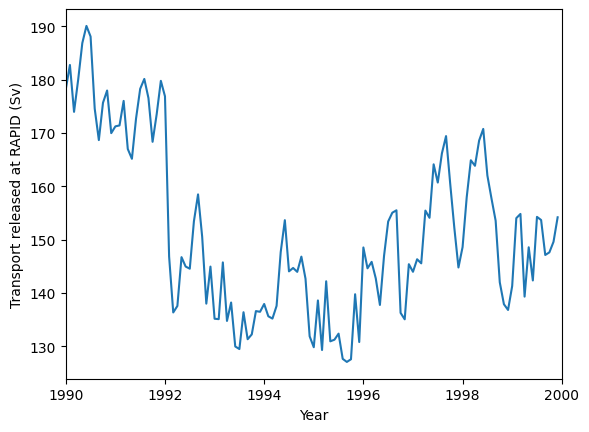

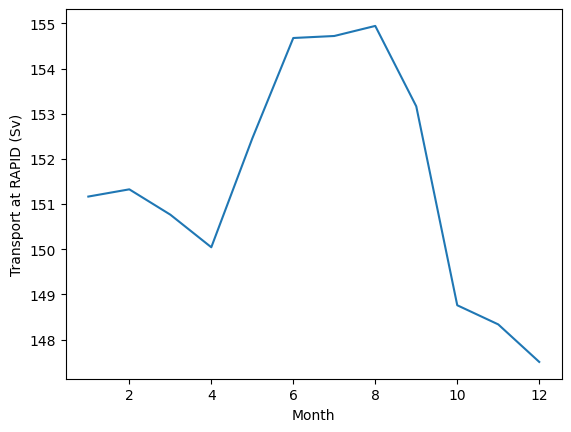

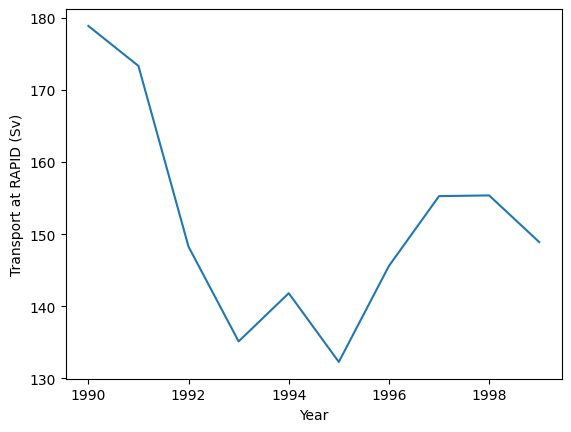

In [4]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj")

results = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

# -------------------------
# 1. Read each monthly file
# -------------------------
for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue

        df = pl.read_parquet(file_path, columns=["subvol", "x"])

        results[key] = (
            df["subvol"]
            .list.first()
            .sum()
            / 1e6
        )

# -------------------------
# 2. Build dataframe
# -------------------------
results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 1)
      .cast(pl.Int32)
      .alias("year"),

    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 2)
      .cast(pl.Int32)
      .alias("month"),
])

results_df = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_RAPID = results_df.select(["time", "subvol_sum"])

# -------------------------
# 3. Time series plot
# -------------------------
plt.figure()
plt.plot(
    results_df_condensed_RAPID["time"],
    results_df_condensed_RAPID["subvol_sum"]
)

plt.xlabel("Year")
plt.ylabel("Transport released at RAPID (Sv)")
#plt.ylim(46, 62)
plt.xlim(1990, 2000)
plt.show()

# -------------------------
# 4. Monthly climatology
# -------------------------
monthly_mean_RAPID = (
    results_df
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.figure()
plt.plot(
    monthly_mean_RAPID["month"],
    monthly_mean_RAPID["subvol_mean"]
)

plt.xlabel("Month")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

# -------------------------
# 5. Annual climatology
# -------------------------
annual_mean_RAPID = (
    results_df
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.figure()
plt.plot(
    annual_mean_RAPID["year"],
    annual_mean_RAPID["subvol_mean"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

[1/120] Processing 1990_01
[2/120] Processing 1990_02
[3/120] Processing 1990_03
[4/120] Processing 1990_04
[5/120] Processing 1990_05
[6/120] Processing 1990_06
[7/120] Processing 1990_07
[8/120] Processing 1990_08
[9/120] Processing 1990_09
[10/120] Processing 1990_10
[11/120] Processing 1990_11
[12/120] Processing 1990_12
[13/120] Processing 1991_01
[14/120] Processing 1991_02
[15/120] Processing 1991_03
[16/120] Processing 1991_04
[17/120] Processing 1991_05
[18/120] Processing 1991_06
[19/120] Processing 1991_07
[20/120] Processing 1991_08
[21/120] Processing 1991_09
[22/120] Processing 1991_10
[23/120] Processing 1991_11
[24/120] Processing 1991_12
[25/120] Processing 1992_01
[26/120] Processing 1992_02
[27/120] Processing 1992_03
[28/120] Processing 1992_04
[29/120] Processing 1992_05
[30/120] Processing 1992_06
[31/120] Processing 1992_07
[32/120] Processing 1992_08
[33/120] Processing 1992_09
[34/120] Processing 1992_10
[35/120] Processing 1992_11
[36/120] Processing 1992_12
[

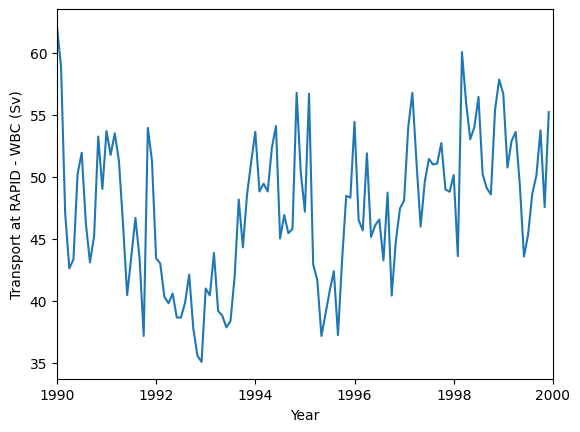

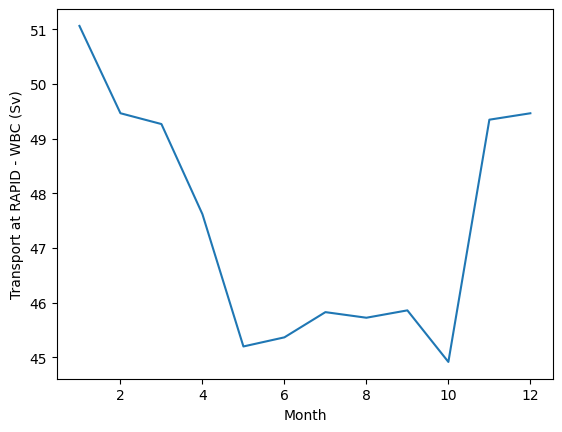

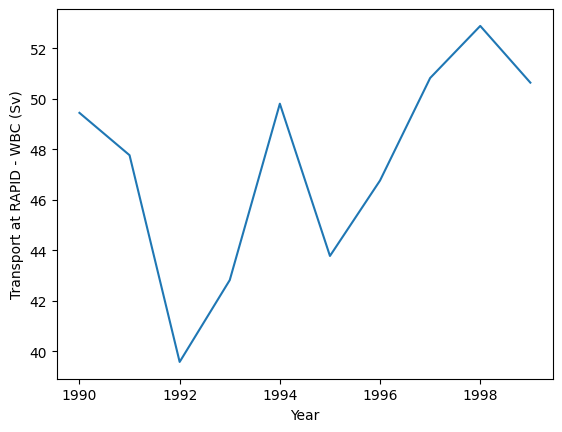

In [5]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj")

results = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

# -------------------------
# 1. Read each monthly file
# -------------------------
for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue

        df = pl.read_parquet(file_path, columns=["subvol", "x"])

        df = df.filter(
            pl.col("x").list.first() <= 854
        )

        results[key] = (
            df["subvol"]
            .list.first()
            .sum()
            / 1e6
        )

# -------------------------
# 2. Build dataframe
# -------------------------
results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 1)
      .cast(pl.Int32)
      .alias("year"),

    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 2)
      .cast(pl.Int32)
      .alias("month"),
])

results_df = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_WBC = results_df.select(["time", "subvol_sum"])

# -------------------------
# 3. Time series plot
# -------------------------
plt.figure()
plt.plot(
    results_df_condensed_WBC["time"],
    results_df_condensed_WBC["subvol_sum"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID - WBC (Sv)")
#plt.ylim(46, 62)
plt.xlim(1990, 2000)
plt.show()

# -------------------------
# 4. Monthly climatology
# -------------------------
monthly_mean_RAPID = (
    results_df
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.figure()
plt.plot(
    monthly_mean_RAPID["month"],
    monthly_mean_RAPID["subvol_mean"]
)

plt.xlabel("Month")
plt.ylabel("Transport at RAPID - WBC (Sv)")
plt.show()

# -------------------------
# 5. Annual climatology
# -------------------------
annual_mean_RAPID = (
    results_df
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.figure()
plt.plot(
    annual_mean_RAPID["year"],
    annual_mean_RAPID["subvol_mean"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID - WBC (Sv)")
plt.show()

[1/120] Processing 1990_01
[2/120] Processing 1990_02
[3/120] Processing 1990_03
[4/120] Processing 1990_04
[5/120] Processing 1990_05
[6/120] Processing 1990_06
[7/120] Processing 1990_07
[8/120] Processing 1990_08
[9/120] Processing 1990_09
[10/120] Processing 1990_10
[11/120] Processing 1990_11
[12/120] Processing 1990_12
[13/120] Processing 1991_01
[14/120] Processing 1991_02
[15/120] Processing 1991_03
[16/120] Processing 1991_04
[17/120] Processing 1991_05
[18/120] Processing 1991_06
[19/120] Processing 1991_07
[20/120] Processing 1991_08
[21/120] Processing 1991_09
[22/120] Processing 1991_10
[23/120] Processing 1991_11
[24/120] Processing 1991_12
[25/120] Processing 1992_01
[26/120] Processing 1992_02
[27/120] Processing 1992_03
[28/120] Processing 1992_04
[29/120] Processing 1992_05
[30/120] Processing 1992_06
[31/120] Processing 1992_07
[32/120] Processing 1992_08
[33/120] Processing 1992_09
[34/120] Processing 1992_10
[35/120] Processing 1992_11
[36/120] Processing 1992_12
[

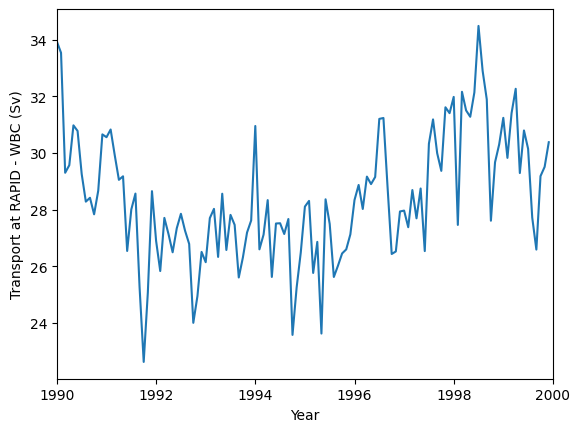

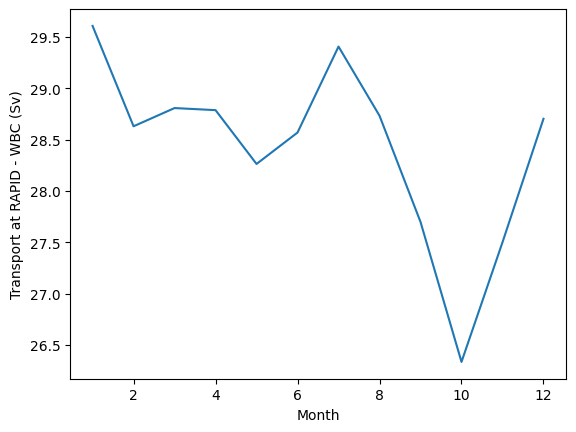

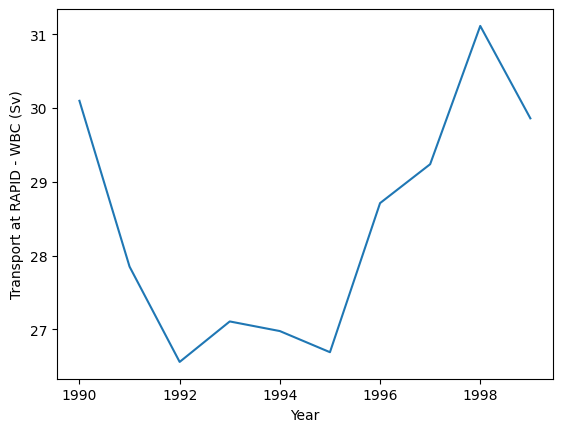

In [10]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj")

results = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

# -------------------------
# 1. Read each monthly file
# -------------------------
for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue

        df = pl.read_parquet(file_path, columns=["subvol", "x"])

        df = df.filter(
            pl.col("x").list.first() <= 838
        )

        results[key] = (
            df["subvol"]
            .list.first()
            .sum()
            / 1e6
        )

# -------------------------
# 2. Build dataframe
# -------------------------
results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 1)
      .cast(pl.Int32)
      .alias("year"),

    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 2)
      .cast(pl.Int32)
      .alias("month"),
])

results_df = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_FC = results_df.select(["time", "subvol_sum"])

# -------------------------
# 3. Time series plot
# -------------------------
plt.figure()
plt.plot(
    results_df_condensed_FC["time"],
    results_df_condensed_FC["subvol_sum"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID - WBC (Sv)")
#plt.ylim(46, 62)
plt.xlim(1990, 2000)
plt.show()

# -------------------------
# 4. Monthly climatology
# -------------------------
monthly_mean_RAPID = (
    results_df
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.figure()
plt.plot(
    monthly_mean_RAPID["month"],
    monthly_mean_RAPID["subvol_mean"]
)

plt.xlabel("Month")
plt.ylabel("Transport at RAPID - WBC (Sv)")
plt.show()

# -------------------------
# 5. Annual climatology
# -------------------------
annual_mean_RAPID = (
    results_df
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.figure()
plt.plot(
    annual_mean_RAPID["year"],
    annual_mean_RAPID["subvol_mean"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID - WBC (Sv)")
plt.show()

[1/120] Processing 1990_01
[2/120] Processing 1990_02
[3/120] Processing 1990_03
[4/120] Processing 1990_04
[5/120] Processing 1990_05
[6/120] Processing 1990_06
[7/120] Processing 1990_07
[8/120] Processing 1990_08
[9/120] Processing 1990_09
[10/120] Processing 1990_10
[11/120] Processing 1990_11
[12/120] Processing 1990_12
[13/120] Processing 1991_01
[14/120] Processing 1991_02
[15/120] Processing 1991_03
[16/120] Processing 1991_04
[17/120] Processing 1991_05
[18/120] Processing 1991_06
[19/120] Processing 1991_07
[20/120] Processing 1991_08
[21/120] Processing 1991_09
[22/120] Processing 1991_10
[23/120] Processing 1991_11
[24/120] Processing 1991_12
[25/120] Processing 1992_01
[26/120] Processing 1992_02
[27/120] Processing 1992_03
[28/120] Processing 1992_04
[29/120] Processing 1992_05
[30/120] Processing 1992_06
[31/120] Processing 1992_07
[32/120] Processing 1992_08
[33/120] Processing 1992_09
[34/120] Processing 1992_10
[35/120] Processing 1992_11
[36/120] Processing 1992_12
[

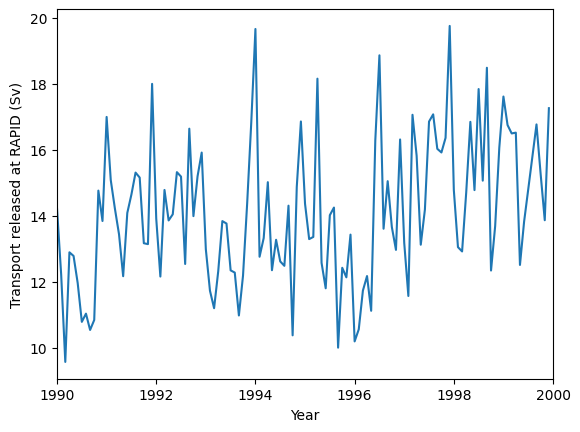

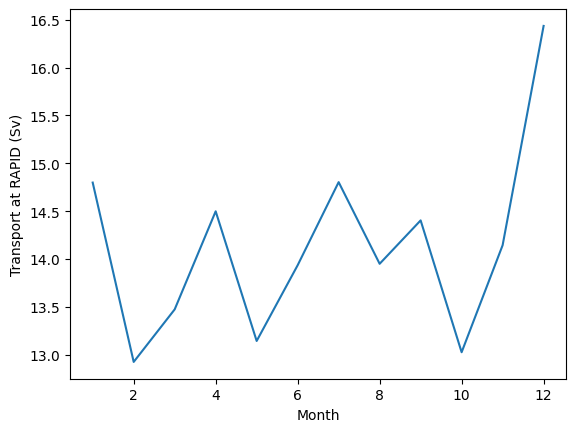

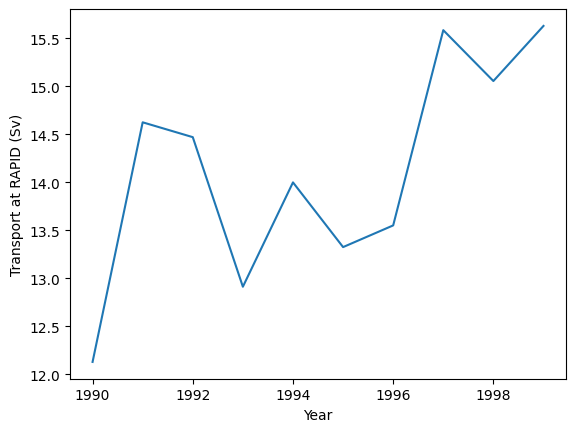

In [6]:
import polars as pl
from pathlib import Path
import matplotlib.pyplot as plt

data_dir = Path("/dssgfs01/scratch/emdh1n25/project_1m_RAPID/processed_traj")

results = {}

# -------------------------
# Progress setup
# -------------------------
total_files = 10 * 12  # 1990–1999 inclusive
processed = 0

# -------------------------
# 1. Read each monthly file
# -------------------------
for year in range(1990, 2000):
    for month in range(1, 13):

        processed += 1
        key = f"{year}_{month:02d}"
        file_path = data_dir / f"{key}.parquet"

        print(f"[{processed}/{total_files}] Processing {key}")

        if not file_path.exists():
            print(f"  Missing {key}")
            continue

        df = pl.read_parquet(file_path, columns=["subvol", "y"])

        df = df.filter(
            pl.col("y").list.eval(pl.element() >= 908).list.any()
        )

        results[key] = (
            df["subvol"]
            .list.first()
            .sum()
            / 1e6
        )

# -------------------------
# 2. Build dataframe
# -------------------------
results_df = pl.DataFrame({
    "year_month": list(results.keys()),
    "subvol_sum": list(results.values())
})

results_df = results_df.with_columns([
    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 1)
      .cast(pl.Int32)
      .alias("year"),

    pl.col("year_month")
      .str.extract(r"(\d{4})_(\d{2})", 2)
      .cast(pl.Int32)
      .alias("month"),
])

results_df = results_df.with_columns([
    (pl.col("year") + (pl.col("month") - 1) / 12).alias("time")
])

results_df_condensed_NOAC = results_df.select(["time", "subvol_sum"])

# -------------------------
# 3. Time series plot
# -------------------------
plt.figure()
plt.plot(
    results_df_condensed_NOAC["time"],
    results_df_condensed_NOAC["subvol_sum"]
)

plt.xlabel("Year")
plt.ylabel("Transport released at RAPID (Sv)")
#plt.ylim(46, 62)
plt.xlim(1990, 2000)
plt.show()

# -------------------------
# 4. Monthly climatology
# -------------------------
monthly_mean_RAPID = (
    results_df
    .group_by("month")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("month")
)

plt.figure()
plt.plot(
    monthly_mean_RAPID["month"],
    monthly_mean_RAPID["subvol_mean"]
)

plt.xlabel("Month")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

# -------------------------
# 5. Annual climatology
# -------------------------
annual_mean_RAPID = (
    results_df
    .group_by("year")
    .agg(pl.col("subvol_sum").mean().alias("subvol_mean"))
    .sort("year")
)

plt.figure()
plt.plot(
    annual_mean_RAPID["year"],
    annual_mean_RAPID["subvol_mean"]
)

plt.xlabel("Year")
plt.ylabel("Transport at RAPID (Sv)")
plt.show()

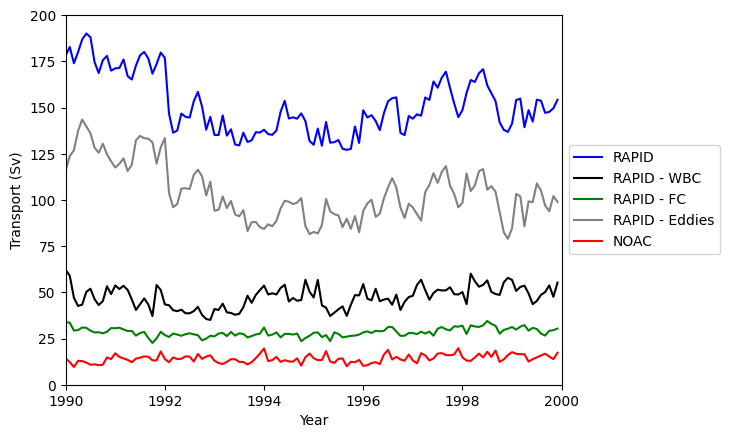

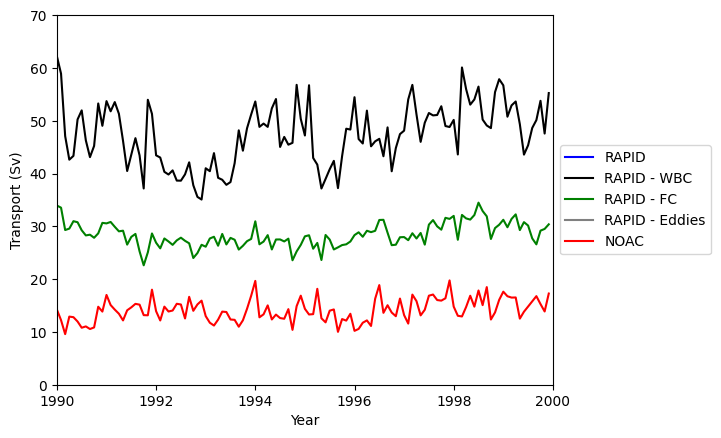

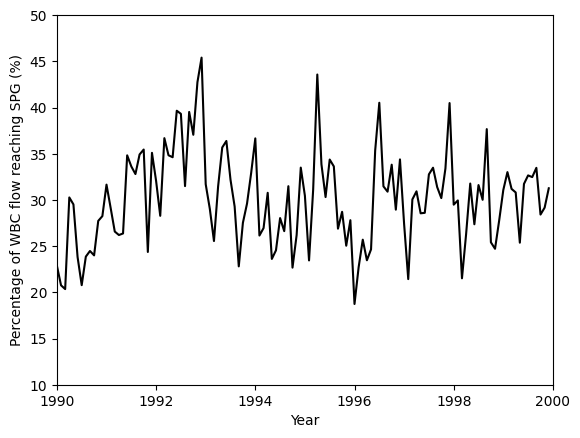

151.48823437649997 47.42571144158331 28.420437228999997 104.06252293491667 14.128766292499995
16.08039368782117 5.896145497204715 2.2485753565018065 15.32412640514827 2.1671256967461447
Mean percentage of WBC flow reaching SPG: 29.791363931151828


In [12]:
# Monthly timeseries

import matplotlib.pyplot as plt

plt.plot(results_df_condensed_RAPID["time"], results_df_condensed_RAPID["subvol_sum"], color = 'blue', label = "RAPID")
plt.plot(results_df_condensed_WBC["time"], results_df_condensed_WBC["subvol_sum"], color = 'black', label = "RAPID - WBC")
plt.plot(results_df_condensed_FC["time"], results_df_condensed_FC["subvol_sum"], color = 'green', label = "RAPID - FC")
plt.plot(results_df_condensed_RAPID["time"], (results_df_condensed_RAPID - results_df_condensed_WBC)["subvol_sum"], color = 'gray', label = "RAPID - Eddies")
plt.plot(results_df_condensed_NOAC["time"], results_df_condensed_NOAC["subvol_sum"], color = 'red', label = "NOAC")
plt.xlabel("Year")
plt.ylabel("Transport (Sv)")
plt.ylim(0, 200)
plt.xlim(1990, 2000)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()



plt.plot(results_df_condensed_RAPID["time"], results_df_condensed_RAPID["subvol_sum"], color = 'blue', label = "RAPID")
plt.plot(results_df_condensed_WBC["time"], results_df_condensed_WBC["subvol_sum"], color = 'black', label = "RAPID - WBC")
plt.plot(results_df_condensed_FC["time"], results_df_condensed_FC["subvol_sum"], color = 'green', label = "RAPID - FC")
plt.plot(results_df_condensed_RAPID["time"], (results_df_condensed_RAPID - results_df_condensed_WBC)["subvol_sum"], color = 'gray', label = "RAPID - Eddies")
plt.plot(results_df_condensed_NOAC["time"], results_df_condensed_NOAC["subvol_sum"], color = 'red', label = "NOAC")
plt.xlabel("Year")
plt.ylabel("Transport (Sv)")
plt.ylim(0, 70)
plt.xlim(1990, 2000)

plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()


fig, ax = plt.subplots()

ax.plot(results_df_condensed_RAPID["time"],
        results_df_condensed_NOAC["subvol_sum"]/results_df_condensed_WBC["subvol_sum"] * 100,
        color='black')

ax.set_xlabel("Year")
ax.set_ylabel("Percentage of WBC flow reaching SPG (%)")
ax.set_ylim(10, 50)
ax.set_xlim(1990, 2000)

# FORCE full frame (this is the key fix)
for spine in ax.spines.values():
    spine.set_visible(True)

plt.show()


mean_RAPID = results_df_condensed_RAPID["subvol_sum"].mean()
mean_WBC   = results_df_condensed_WBC["subvol_sum"].mean()
mean_FC   = results_df_condensed_FC["subvol_sum"].mean()
mean_eddies = (results_df_condensed_RAPID["subvol_sum"] - results_df_condensed_WBC["subvol_sum"]).mean()
mean_NOAC  = results_df_condensed_NOAC["subvol_sum"].mean()

print(mean_RAPID, mean_WBC, mean_FC, mean_eddies, mean_NOAC)

std_RAPID = results_df_condensed_RAPID["subvol_sum"].std()
std_WBC   = results_df_condensed_WBC["subvol_sum"].std()
std_FC   = results_df_condensed_FC["subvol_sum"].std()
std_eddies = (results_df_condensed_RAPID["subvol_sum"] - results_df_condensed_WBC["subvol_sum"]).std()
std_NOAC  = results_df_condensed_NOAC["subvol_sum"].std()

print(std_RAPID, std_WBC, std_FC, std_eddies, std_NOAC)

print("Mean percentage of WBC flow reaching SPG:", mean_NOAC/mean_WBC * 100)

